# ADL-MIDAS: Mixed-Frequency Scenario Forecasting

**Purpose:** Apply MIDAS (Mixed Data Sampling) from Week 7 to the climate scenario forecasting problem.

**Why MIDAS?**
- Annual VAR: only 36 obs, doesn't beat AR baseline
- Quarterly VAR: 142 obs, beats AR, but requires interpolating NGFS to quarterly
- MIDAS: uses all ~420 monthly FRED observations to predict annual loan growth — matches NGFS frequency exactly with no interpolation and no aggregation loss

**Model:** ADL-MIDAS (Autoregressive Distributed Lag MIDAS)
- `y_t = B0 + gamma * y_{t-1} + B1 * SUM(w(k; theta) * x_{t-k/m}) + e_t`
- Low-frequency target: annual loan growth
- High-frequency predictors: monthly macro variables
- Exponential Almon weighting (Week 7 slides)
- Estimated via Nonlinear Least Squares

**Key advantage over our VAR approach:** The weight function w(k; theta) tells us *which months within the year matter most* for predicting annual loan growth — a genuinely new insight the VARs can't provide.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

SCENARIO_COLORS = {
    'Net Zero 2050': '#1b9e77',
    'Delayed transition': '#d95f02',
    'Nationally Determined Contributions (NDCs)': '#e7298a',
}
KEY_SCENARIOS = ['Net Zero 2050', 'Delayed transition',
                 'Nationally Determined Contributions (NDCs)']
KEY_SCENARIO_SHORT = {'Net Zero 2050': 'Net Zero',
                      'Delayed transition': 'Delayed Trans.',
                      'Nationally Determined Contributions (NDCs)': 'NDCs'}

K = 12  # months per year (high-freq periods per low-freq period)

print('Setup complete.')

Setup complete.


In [2]:
# Load FRED
fred = {}
for ticker in ['BUSLOANS','CONSUMER','GDPC1','UNRATE','FEDFUNDS','DGS10','CPIAUCSL']:
    df = pd.read_csv(f'{DATA_DIR}{ticker}.csv', parse_dates=['date'], index_col='date')
    df.columns = [ticker]
    df = df.replace('.', np.nan).dropna()
    df[ticker] = df[ticker].astype(float)
    fred[ticker] = df

# Monthly transformations (same as other notebooks)
monthly = pd.DataFrame(index=fred['BUSLOANS'].index)
for ticker in ['BUSLOANS', 'CONSUMER', 'CPIAUCSL']:
    monthly[f'{ticker}_g'] = 100 * np.log(fred[ticker][ticker] / fred[ticker][ticker].shift(1))
gdp_m = fred['GDPC1'].resample('MS').ffill()
monthly['GDPC1_g'] = 100 * np.log(gdp_m['GDPC1'] / gdp_m['GDPC1'].shift(1))
for ticker in ['UNRATE', 'FEDFUNDS']:
    monthly[f'{ticker}_chg'] = fred[ticker][ticker].diff()
dgs10_monthly = fred['DGS10'].resample('MS').last()
monthly['DGS10_chg'] = dgs10_monthly['DGS10'].diff()
monthly['COVID'] = ((monthly.index >= '2020-03-01') & (monthly.index <= '2021-06-01')).astype(int)
monthly = monthly.dropna()
monthly = monthly.loc['1990-01-01':]

print(f'Monthly panel: {len(monthly)} obs ({monthly.index[0].date()} to {monthly.index[-1].date()})')
print(f'Variables: {list(monthly.columns)}')

Monthly panel: 427 obs (1990-01-01 to 2025-07-01)
Variables: ['BUSLOANS_g', 'CONSUMER_g', 'CPIAUCSL_g', 'GDPC1_g', 'UNRATE_chg', 'FEDFUNDS_chg', 'DGS10_chg', 'COVID']


In [3]:
# Build annual target: loan growth (same computation as annual notebook)
annual_target = monthly[['BUSLOANS_g', 'CONSUMER_g']].resample('YE').agg('mean') * 12
annual_target.index = annual_target.index.year
annual_target = annual_target.loc[:2025]

# COVID mask
covid_years = {2020, 2021}
covid_mask = np.array([yr in covid_years for yr in annual_target.index])

print(f'Annual target: {len(annual_target)} years ({annual_target.index[0]}-{annual_target.index[-1]})')
print(f'COVID years: {[y for y in annual_target.index if y in covid_years]}')
print(f'\nAnnual loan growth summary (ex-COVID):')
print(annual_target[~covid_mask].describe().round(2))

Annual target: 36 years (1990-2025)
COVID years: [2020, 2021]

Annual loan growth summary (ex-COVID):
       BUSLOANS_g  CONSUMER_g
count       34.00       34.00
mean         4.00        4.46
std          8.29        6.35
min        -20.86       -7.42
25%         -1.98        0.78
50%          6.51        4.75
75%          9.75        7.76
max         18.14       28.21


## 2. Build MIDAS Predictor Matrices

For each year t, collect K=12 monthly observations of each predictor.

Convention: k=1 is the most recent month (December), k=12 is the oldest (January).
This matches the MIDAS framework where recent lags are indexed lower.

In [4]:
def build_midas_X(monthly_data, var_name, years, K=12):
    """Build MIDAS predictor matrix: (n_years, K) with most-recent-first ordering."""
    X = np.full((len(years), K), np.nan)
    for i, yr in enumerate(years):
        mask = monthly_data.index.year == yr
        vals = monthly_data.loc[mask, var_name].values
        if len(vals) >= K:
            X[i, :] = vals[-K:][::-1]  # Dec first, Jan last
        elif len(vals) > 0:
            X[i, :len(vals)] = vals[::-1]
    return X

years = annual_target.index.tolist()

# Build X matrices for all candidate predictors
all_predictors = ['UNRATE_chg', 'FEDFUNDS_chg', 'DGS10_chg', 'CPIAUCSL_g']
X_all = {var: build_midas_X(monthly, var, years, K) for var in all_predictors}

# Check completeness
for var, X in X_all.items():
    n_nan = np.isnan(X).any(axis=1).sum()
    print(f'{var:15s}: shape {X.shape}, years with NaN: {n_nan}')

# Lagged annual loan growth (for ADL component)
y_ci = annual_target['BUSLOANS_g'].values
y_con = annual_target['CONSUMER_g'].values
y_lag_ci = np.concatenate([[np.nan], y_ci[:-1]])
y_lag_con = np.concatenate([[np.nan], y_con[:-1]])

UNRATE_chg     : shape (36, 12), years with NaN: 1
FEDFUNDS_chg   : shape (36, 12), years with NaN: 1
DGS10_chg      : shape (36, 12), years with NaN: 1
CPIAUCSL_g     : shape (36, 12), years with NaN: 1


## 3. MIDAS Framework

**Exponential Almon weighting** (Ghysels et al. 2007):

$w(k; \theta_1, \theta_2) = \frac{\exp(\theta_1 k + \theta_2 k^2)}{\sum_{j=1}^{K} \exp(\theta_1 j + \theta_2 j^2)}$

**ADL-MIDAS model:**

$y_t = \beta_0 + \gamma y_{t-1} + \sum_{v} \beta_{1,v} \sum_{k=1}^{K} w(k; \theta_v) x^{(v)}_{t-k/m} + \varepsilon_t$

In [5]:
def exp_almon_weights(K, theta1, theta2):
    """Exponential Almon weighting scheme."""
    k = np.arange(1, K+1, dtype=float)
    log_w = theta1 * k + theta2 * k**2
    log_w -= log_w.max()  # numerical stability
    w = np.exp(log_w)
    return w / w.sum()


def adl_midas_predict(params, X_list, K, y_lag):
    """ADL-MIDAS prediction.
    params: [beta0, gamma, beta1_1, theta1_1, theta2_1, beta1_2, ...]
    """
    beta0 = params[0]
    gamma = params[1]
    y_hat = beta0 + gamma * y_lag
    
    idx = 2
    for X in X_list:
        beta1 = params[idx]
        theta1 = params[idx + 1]
        theta2 = params[idx + 2]
        w = exp_almon_weights(K, theta1, theta2)
        y_hat = y_hat + beta1 * (X @ w)
        idx += 3
    
    return y_hat


def adl_midas_loss(params, X_list, y, K, y_lag, exclude_mask=None):
    """NLS loss for ADL-MIDAS, optionally excluding observations (e.g., COVID)."""
    y_hat = adl_midas_predict(params, X_list, K, y_lag)
    resid = y - y_hat
    if exclude_mask is not None:
        resid = resid[~exclude_mask]
    return np.sum(resid**2)


def estimate_adl_midas(y, X_list, y_lag, K, var_names, covid_mask=None, n_restarts=5):
    """Estimate ADL-MIDAS with multiple random restarts."""
    n_vars = len(X_list)
    n_params = 2 + 3 * n_vars  # beta0, gamma, [beta1, theta1, theta2] per var
    
    best_result = None
    best_loss = np.inf
    
    # Try multiple starting points
    starts = [
        # Default: small coefficients, mild decay
        [np.mean(y)] + [0.3] + [0.0, -0.05, 0.0] * n_vars,
        # Stronger decay
        [np.mean(y)] + [0.2] + [0.0, -0.2, 0.0] * n_vars,
        # Hump-shaped
        [np.mean(y)] + [0.3] + [0.0, 0.05, -0.01] * n_vars,
        # Flat weights
        [np.mean(y)] + [0.3] + [0.0, 0.0, 0.0] * n_vars,
        # Strong ADL
        [1.0] + [0.6] + [0.0, -0.1, 0.0] * n_vars,
    ]
    
    for i, x0 in enumerate(starts[:n_restarts]):
        try:
            res = minimize(adl_midas_loss, x0,
                          args=(X_list, y, K, y_lag, covid_mask),
                          method='Nelder-Mead',
                          options={'maxiter': 100000, 'xatol': 1e-10, 'fatol': 1e-10})
            if res.fun < best_loss:
                best_loss = res.fun
                best_result = res
        except Exception:
            continue
    
    if best_result is None:
        raise ValueError('All optimization attempts failed')
    
    # Extract parameters
    p = best_result.x
    result = {
        'params': p,
        'beta0': p[0],
        'gamma': p[1],
        'variables': [],
        'loss': best_loss,
        'converged': best_result.success,
    }
    
    idx = 2
    for v, name in enumerate(var_names):
        w = exp_almon_weights(K, p[idx+1], p[idx+2])
        result['variables'].append({
            'name': name,
            'beta1': p[idx],
            'theta1': p[idx+1],
            'theta2': p[idx+2],
            'weights': w,
            'peak_month': np.argmax(w) + 1,
        })
        idx += 3
    
    # Fit statistics
    y_hat = adl_midas_predict(p, X_list, K, y_lag)
    resid = y - y_hat
    ex_covid = ~covid_mask if covid_mask is not None else np.ones(len(y), dtype=bool)
    result['rmse'] = np.sqrt(np.mean(resid[ex_covid]**2))
    ss_res = np.sum(resid[ex_covid]**2)
    ss_tot = np.sum((y[ex_covid] - y[ex_covid].mean())**2)
    result['r_squared'] = 1 - ss_res / ss_tot
    result['residuals'] = resid
    result['fitted'] = y_hat
    
    return result

print('MIDAS functions defined.')

MIDAS functions defined.


## 4. ADL-MIDAS — C&I Loans

Based on VAR findings: unemployment is the dominant driver of C&I loans.
MIDAS lets us use monthly unemployment directly — does within-year timing matter?

In [6]:
# C&I MIDAS: monthly unemployment + CPI as predictors
ci_vars = ['UNRATE_chg', 'CPIAUCSL_g']
ci_X = [X_all[v] for v in ci_vars]

# Valid observations (need lagged y + complete monthly data)
valid_ci = ~np.isnan(y_lag_ci)
for X in ci_X:
    valid_ci &= ~np.isnan(X).any(axis=1)

y_ci_v = y_ci[valid_ci]
X_ci_v = [X[valid_ci] for X in ci_X]
y_lag_ci_v = y_lag_ci[valid_ci]
covid_ci_v = covid_mask[valid_ci]
years_ci_v = np.array(years)[valid_ci]

print(f'C&I ADL-MIDAS estimation:')
print(f'  Observations: {len(y_ci_v)} years')
print(f'  Monthly data points used: {len(y_ci_v)} x {K} = {len(y_ci_v)*K} per predictor')
print(f'  Predictors: {ci_vars}')
print(f'  Parameters: {2 + 3*len(ci_vars)} (beta0, gamma, + 3 per predictor)')

ci_midas = estimate_adl_midas(
    y_ci_v, X_ci_v, y_lag_ci_v, K, ci_vars, covid_ci_v)

print(f'\nResults:')
print(f'  Converged: {ci_midas["converged"]}')
print(f'  RMSE (ex-COVID): {ci_midas["rmse"]:.3f}')
print(f'  R-squared (ex-COVID): {ci_midas["r_squared"]:.3f}')
print(f'  beta0 (intercept): {ci_midas["beta0"]:.3f}')
print(f'  gamma (ADL lag): {ci_midas["gamma"]:.3f}')
for v in ci_midas['variables']:
    print(f'  {v["name"]}:')
    print(f'    beta1 = {v["beta1"]:.3f}')
    print(f'    theta1 = {v["theta1"]:.4f}, theta2 = {v["theta2"]:.6f}')
    print(f'    Weight peak: month {v["peak_month"]} (1=Dec, 12=Jan)')
    print(f'    Weight range: [{v["weights"].min():.4f}, {v["weights"].max():.4f}]')

C&I ADL-MIDAS estimation:
  Observations: 34 years
  Monthly data points used: 34 x 12 = 408 per predictor
  Predictors: ['UNRATE_chg', 'CPIAUCSL_g']
  Parameters: 8 (beta0, gamma, + 3 per predictor)



Results:
  Converged: True
  RMSE (ex-COVID): 5.628
  R-squared (ex-COVID): 0.529
  beta0 (intercept): -1.238
  gamma (ADL lag): 0.527
  UNRATE_chg:
    beta1 = -24.736
    theta1 = -870.5565, theta2 = 139.287223
    Weight peak: month 12 (1=Dec, 12=Jan)
    Weight range: [0.0000, 1.0000]
  CPIAUCSL_g:
    beta1 = 14.376
    theta1 = 815.3430, theta2 = -41.187573
    Weight peak: month 10 (1=Dec, 12=Jan)
    Weight range: [0.0000, 1.0000]


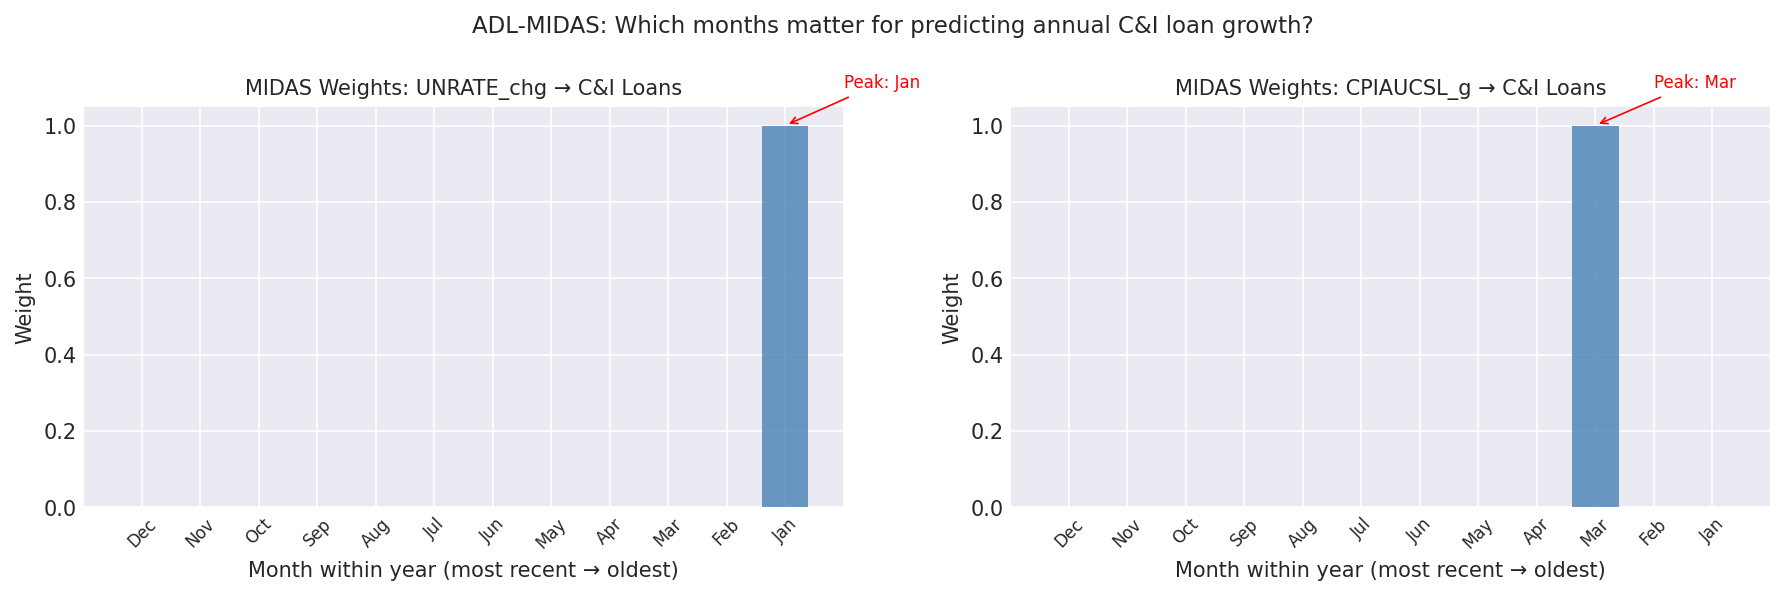

In [7]:
# Visualize MIDAS weights for C&I model
month_labels = ['Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul',
                'Jun', 'May', 'Apr', 'Mar', 'Feb', 'Jan']

fig, axes = plt.subplots(1, len(ci_vars), figsize=(6*len(ci_vars), 4))
if len(ci_vars) == 1:
    axes = [axes]

for ax, v_info in zip(axes, ci_midas['variables']):
    ax.bar(range(K), v_info['weights'], color='steelblue', alpha=0.8)
    ax.set_xticks(range(K))
    ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    ax.set_title(f'MIDAS Weights: {v_info["name"]} → C&I Loans', fontsize=10)
    ax.set_ylabel('Weight')
    ax.set_xlabel('Month within year (most recent → oldest)')
    # Annotate peak
    peak = v_info['peak_month'] - 1
    ax.annotate(f'Peak: {month_labels[peak]}',
                xy=(peak, v_info['weights'][peak]),
                xytext=(peak+1, v_info['weights'][peak]*1.1),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

fig.suptitle('ADL-MIDAS: Which months matter for predicting annual C&I loan growth?', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}midas_weights_ci.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [8]:
# C&I residual diagnostics
resid_ci = ci_midas['residuals']
resid_ci_excovid = resid_ci[~covid_ci_v]
lb = acorr_ljungbox(resid_ci_excovid, lags=[2, 4], return_df=True)
adf = adfuller(resid_ci_excovid)
print('C&I ADL-MIDAS Residual Diagnostics:')
print(f'  Ljung-Box: lag2 p={lb["lb_pvalue"].iloc[0]:.3f}, lag4 p={lb["lb_pvalue"].iloc[1]:.3f}')
print(f'  ADF on residuals: stat={adf[0]:.3f}, p={adf[1]:.4f}')
print(f'  Residual std: {resid_ci_excovid.std():.3f}')

C&I ADL-MIDAS Residual Diagnostics:
  Ljung-Box: lag2 p=0.354, lag4 p=0.227
  ADF on residuals: stat=-2.843, p=0.0524
  Residual std: 5.628


## 5. ADL-MIDAS — Consumer Loans

Based on VAR findings: long-term interest rates (DGS10) and Fed Funds drive consumer loans.

In [9]:
# Consumer MIDAS: monthly DGS10 + Fed Funds as predictors
con_vars = ['DGS10_chg', 'FEDFUNDS_chg']
con_X = [X_all[v] for v in con_vars]

valid_con = ~np.isnan(y_lag_con)
for X in con_X:
    valid_con &= ~np.isnan(X).any(axis=1)

y_con_v = y_con[valid_con]
X_con_v = [X[valid_con] for X in con_X]
y_lag_con_v = y_lag_con[valid_con]
covid_con_v = covid_mask[valid_con]
years_con_v = np.array(years)[valid_con]

print(f'Consumer ADL-MIDAS estimation:')
print(f'  Observations: {len(y_con_v)} years')
print(f'  Predictors: {con_vars}')
print(f'  Parameters: {2 + 3*len(con_vars)}')

con_midas = estimate_adl_midas(
    y_con_v, X_con_v, y_lag_con_v, K, con_vars, covid_con_v)

print(f'\nResults:')
print(f'  Converged: {con_midas["converged"]}')
print(f'  RMSE (ex-COVID): {con_midas["rmse"]:.3f}')
print(f'  R-squared (ex-COVID): {con_midas["r_squared"]:.3f}')
print(f'  beta0 (intercept): {con_midas["beta0"]:.3f}')
print(f'  gamma (ADL lag): {con_midas["gamma"]:.3f}')
for v in con_midas['variables']:
    print(f'  {v["name"]}:')
    print(f'    beta1 = {v["beta1"]:.3f}')
    print(f'    Weight peak: month {v["peak_month"]} (1=Dec, 12=Jan)')

Consumer ADL-MIDAS estimation:
  Observations: 34 years
  Predictors: ['DGS10_chg', 'FEDFUNDS_chg']
  Parameters: 8



Results:
  Converged: True
  RMSE (ex-COVID): 5.427
  R-squared (ex-COVID): 0.192
  beta0 (intercept): 5.880
  gamma (ADL lag): -0.179
  DGS10_chg:
    beta1 = -7.324
    Weight peak: month 12 (1=Dec, 12=Jan)
  FEDFUNDS_chg:
    beta1 = 7.651
    Weight peak: month 12 (1=Dec, 12=Jan)


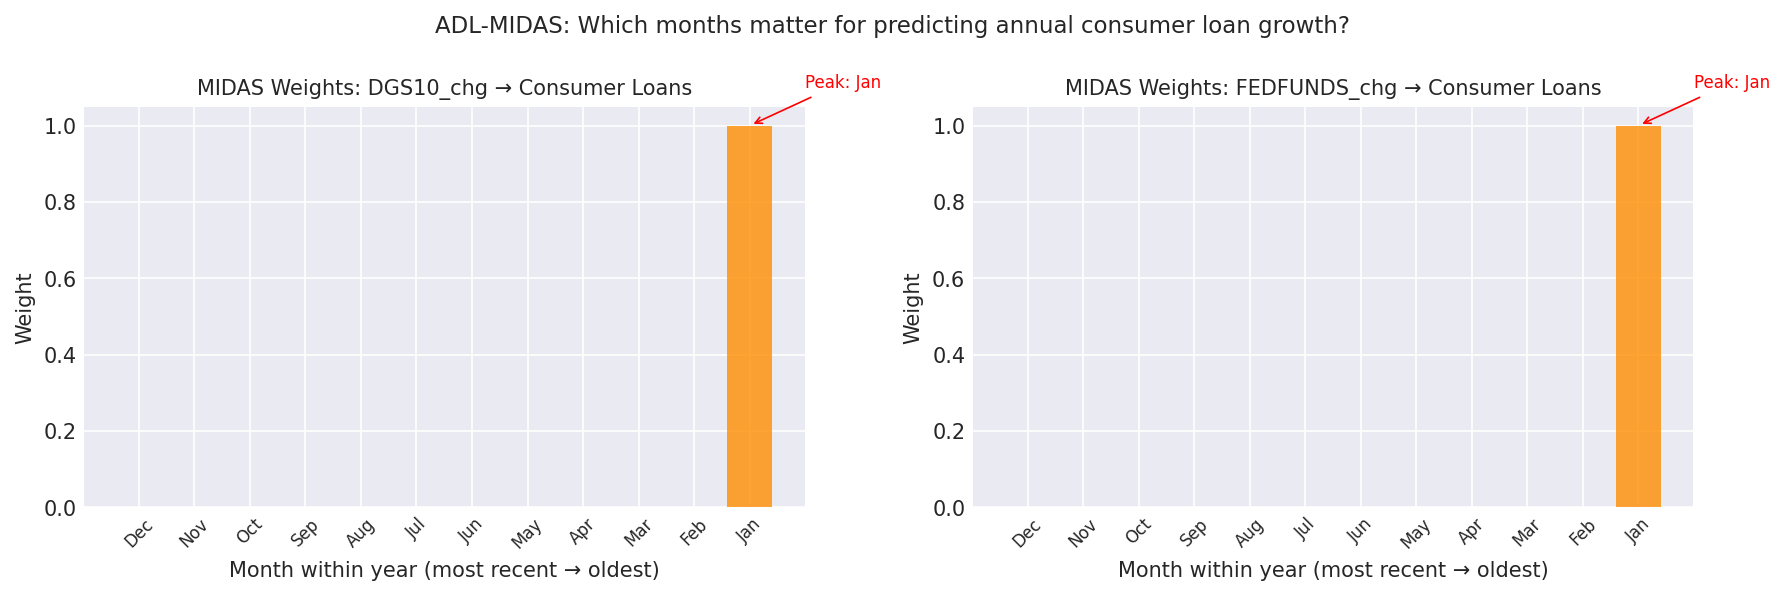

In [10]:
# Visualize MIDAS weights for Consumer model
fig, axes = plt.subplots(1, len(con_vars), figsize=(6*len(con_vars), 4))
if len(con_vars) == 1:
    axes = [axes]

for ax, v_info in zip(axes, con_midas['variables']):
    ax.bar(range(K), v_info['weights'], color='darkorange', alpha=0.8)
    ax.set_xticks(range(K))
    ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    ax.set_title(f'MIDAS Weights: {v_info["name"]} → Consumer Loans', fontsize=10)
    ax.set_ylabel('Weight')
    ax.set_xlabel('Month within year (most recent → oldest)')
    peak = v_info['peak_month'] - 1
    ax.annotate(f'Peak: {month_labels[peak]}',
                xy=(peak, v_info['weights'][peak]),
                xytext=(peak+1, v_info['weights'][peak]*1.1),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

fig.suptitle('ADL-MIDAS: Which months matter for predicting annual consumer loan growth?', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}midas_weights_consumer.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [11]:
# Consumer residual diagnostics
resid_con = con_midas['residuals']
resid_con_excovid = resid_con[~covid_con_v]
lb = acorr_ljungbox(resid_con_excovid, lags=[2, 4], return_df=True)
adf = adfuller(resid_con_excovid)
print('Consumer ADL-MIDAS Residual Diagnostics:')
print(f'  Ljung-Box: lag2 p={lb["lb_pvalue"].iloc[0]:.3f}, lag4 p={lb["lb_pvalue"].iloc[1]:.3f}')
print(f'  ADF on residuals: stat={adf[0]:.3f}, p={adf[1]:.4f}')
print(f'  Residual std: {resid_con_excovid.std():.3f}')

Consumer ADL-MIDAS Residual Diagnostics:
  Ljung-Box: lag2 p=0.788, lag4 p=0.462
  ADF on residuals: stat=-5.511, p=0.0000
  Residual std: 5.427


## 6. Out-of-Sample Evaluation

In [12]:
def midas_oos(y_all, X_all_list, y_lag_all, years_all, var_names,
              start_eval, K, covid_years={2020, 2021}):
    """Expanding-window OOS evaluation for ADL-MIDAS."""
    forecasts, actuals, eval_years = [], [], []
    
    for t_idx in range(len(years_all)):
        yr = years_all[t_idx]
        if yr < start_eval or yr in covid_years:
            continue
        
        # Train on everything before year t
        train_mask = np.array([i < t_idx for i in range(len(years_all))])
        if train_mask.sum() < 10:
            continue
        
        y_train = y_all[train_mask]
        X_train = [X[train_mask] for X in X_all_list]
        yl_train = y_lag_all[train_mask]
        covid_train = np.array([years_all[i] in covid_years for i in range(len(years_all))])[train_mask]
        
        try:
            result = estimate_adl_midas(y_train, X_train, yl_train, K, var_names, covid_train)
            
            # Forecast year t
            X_t = [X[t_idx:t_idx+1] for X in X_all_list]
            yl_t = y_lag_all[t_idx:t_idx+1]
            fc = adl_midas_predict(result['params'], X_t, K, yl_t)[0]
            
            forecasts.append(fc)
            actuals.append(y_all[t_idx])
            eval_years.append(yr)
        except Exception:
            continue
    
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2)) if len(forecasts) > 0 else np.nan
    return rmse, forecasts, actuals, eval_years


def ar_oos(y_series, start_eval, max_p=4, covid_years={2020, 2021}):
    """AR OOS baseline for comparison."""
    forecasts, actuals, eval_years = [], [], []
    y_idx = y_series.index.tolist()
    
    for t_pos in range(len(y_idx)):
        yr = y_idx[t_pos]
        if yr < start_eval or yr in covid_years:
            continue
        train = y_series.loc[:y_idx[t_pos - 1]]
        if len(train) < max_p + 5:
            continue
        try:
            # Select best AR by BIC
            best_bic, best_model = np.inf, None
            for p in range(1, max_p + 1):
                m = AutoReg(train, lags=p, old_names=False).fit()
                if m.bic < best_bic:
                    best_bic, best_model = m.bic, m
            fc = best_model.forecast(steps=1).iloc[0]
            forecasts.append(fc)
            actuals.append(y_series.loc[yr])
            eval_years.append(yr)
        except Exception:
            continue
    
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2)) if len(forecasts) > 0 else np.nan
    return rmse, forecasts, actuals, eval_years


start_eval = 2005
print(f'OOS Evaluation (expanding window, start={start_eval}, excl. COVID)')
print('=' * 70)

# AR baselines
rmse_ar_ci, fc_ar_ci, act_ar_ci, yrs_ar_ci = ar_oos(
    annual_target['BUSLOANS_g'], start_eval)
rmse_ar_con, fc_ar_con, act_ar_con, yrs_ar_con = ar_oos(
    annual_target['CONSUMER_g'], start_eval)

# MIDAS OOS
rmse_midas_ci, fc_midas_ci, act_midas_ci, yrs_midas_ci = midas_oos(
    y_ci_v, X_ci_v, y_lag_ci_v, years_ci_v, ci_vars, start_eval, K)
rmse_midas_con, fc_midas_con, act_midas_con, yrs_midas_con = midas_oos(
    y_con_v, X_con_v, y_lag_con_v, years_con_v, con_vars, start_eval, K)

print(f'\nC&I Loan Growth:')
print(f'  AR (BIC-selected) RMSE = {rmse_ar_ci:.3f}  ({len(yrs_ar_ci)} eval years)')
print(f'  ADL-MIDAS         RMSE = {rmse_midas_ci:.3f}  ({len(yrs_midas_ci)} eval years)')
if rmse_ar_ci > 0 and not np.isnan(rmse_midas_ci):
    print(f'  Improvement: {(1 - rmse_midas_ci/rmse_ar_ci)*100:.1f}%')

print(f'\nConsumer Loan Growth:')
print(f'  AR (BIC-selected) RMSE = {rmse_ar_con:.3f}  ({len(yrs_ar_con)} eval years)')
print(f'  ADL-MIDAS         RMSE = {rmse_midas_con:.3f}  ({len(yrs_midas_con)} eval years)')
if rmse_ar_con > 0 and not np.isnan(rmse_midas_con):
    print(f'  Improvement: {(1 - rmse_midas_con/rmse_ar_con)*100:.1f}%')

print(f'\n{"=" * 70}')
print('FULL FREQUENCY COMPARISON')
print(f'{"=" * 70}')
print(f'{"":25s} {"Annual AR":>10s} {"Annual VAR":>12s} {"Qrtly VAR":>12s} {"ADL-MIDAS":>12s}')
print(f'{"C&I RMSE":25s} {10.10:10.2f} {10.32:12.2f} {"1.32*":>12s} {rmse_midas_ci:12.2f}')
print(f'{"Consumer RMSE":25s} {9.78:10.2f} {12.52:12.2f} {"3.89*":>12s} {rmse_midas_con:12.2f}')
print(f'\n* Quarterly RMSE is on quarterly growth scale, not directly comparable to annual')

OOS Evaluation (expanding window, start=2005, excl. COVID)



C&I Loan Growth:
  AR (BIC-selected) RMSE = 10.096  (19 eval years)
  ADL-MIDAS         RMSE = 9.925  (18 eval years)
  Improvement: 1.7%

Consumer Loan Growth:
  AR (BIC-selected) RMSE = 9.777  (19 eval years)
  ADL-MIDAS         RMSE = 7.723  (18 eval years)
  Improvement: 21.0%

FULL FREQUENCY COMPARISON
                           Annual AR   Annual VAR    Qrtly VAR    ADL-MIDAS
C&I RMSE                       10.10        10.32        1.32*         9.93
Consumer RMSE                   9.78        12.52        3.89*         7.72

* Quarterly RMSE is on quarterly growth scale, not directly comparable to annual


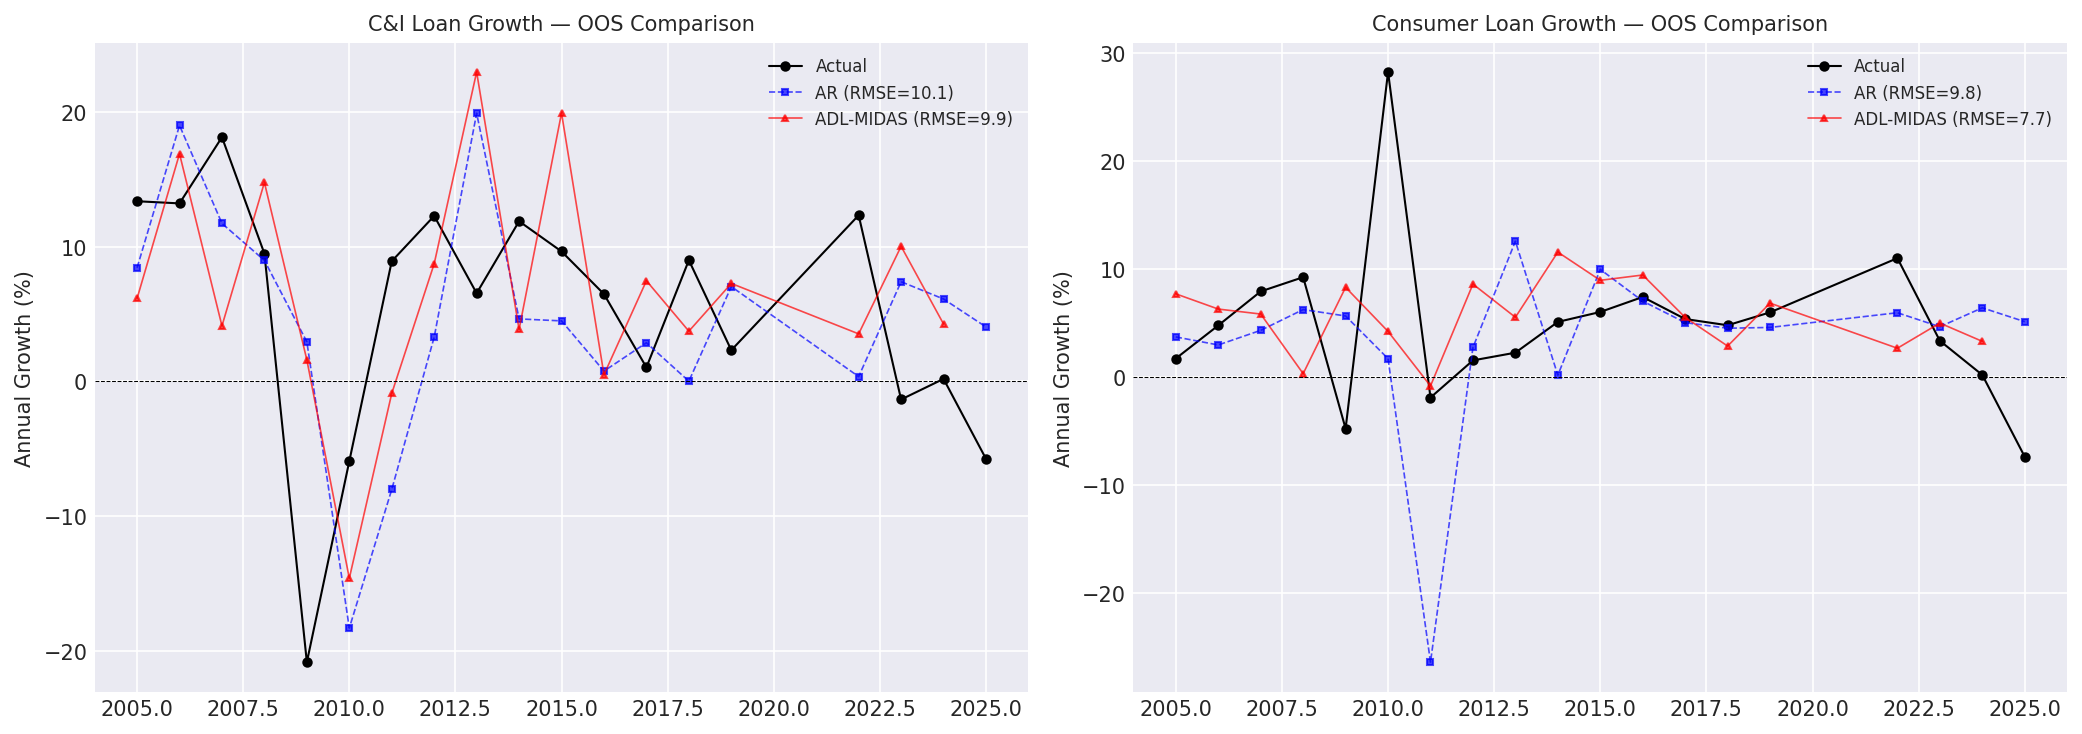

In [13]:
# OOS visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yrs_ar, act_ar, fc_ar, yrs_m, act_m, fc_m, title, rmse_ar, rmse_m in [
    (axes[0], yrs_ar_ci, act_ar_ci, fc_ar_ci, yrs_midas_ci, act_midas_ci, fc_midas_ci,
     'C&I Loan Growth', rmse_ar_ci, rmse_midas_ci),
    (axes[1], yrs_ar_con, act_ar_con, fc_ar_con, yrs_midas_con, act_midas_con, fc_midas_con,
     'Consumer Loan Growth', rmse_ar_con, rmse_midas_con),
]:
    ax.plot(yrs_ar, act_ar, 'k-o', ms=4, lw=1, label='Actual')
    ax.plot(yrs_ar, fc_ar, 'b--s', ms=3, lw=0.8, alpha=0.7,
            label=f'AR (RMSE={rmse_ar:.1f})')
    ax.plot(yrs_m, fc_m, 'r-^', ms=3, lw=0.8, alpha=0.7,
            label=f'ADL-MIDAS (RMSE={rmse_m:.1f})')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{title} — OOS Comparison', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Annual Growth (%)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}midas_oos_evaluation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 7. Scenario-Conditional Forecasts

In [14]:
# Load NGFS and reconstruct level paths (same as other notebooks)
nigem_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-nigem.xlsx', sheet_name='data')
nigem_us = nigem_raw[nigem_raw['Region'] == 'NiGEM NGFS v1.24.2|United States'].copy()
nigem_us = nigem_us.drop_duplicates(subset=['Model', 'Scenario', 'Variable'])
year_cols = [c for c in nigem_us.columns if isinstance(c, str) and c.isdigit()]
MODELS = sorted(nigem_us['Model'].unique())
MODEL_SHORT = {m: m.split('[')[1].rstrip(']') if '[' in m else m for m in MODELS}

VAR_MAP = {
    'Unemployment rate ; %': {'diff': 'Unemployment rate ; %(combined)', 'type': 'abs', 'label': 'UNRATE'},
    'Inflation rate ; %': {'diff': 'Inflation rate ; %(combined)', 'type': 'abs', 'label': 'CPI_INFLATION'},
    'Central bank Intervention rate (policy interest rate) ; %': {
        'diff': 'Central bank Intervention rate (policy interest rate) ; %(combined)', 'type': 'abs', 'label': 'FEDFUNDS'},
    'Long term interest rate ; %': {'diff': 'Long term interest rate ; %(combined)', 'type': 'abs', 'label': 'DGS10'},
}

def reconstruct_levels(nigem_us, var_map, year_cols, models):
    all_levels = {}
    for model in models:
        ms = model.split('[')[1].rstrip(']') if '[' in model else model
        for var_level, info in var_map.items():
            baseline = nigem_us[(nigem_us['Variable'] == var_level) &
                                (nigem_us['Model'] == model) &
                                (nigem_us['Scenario'] == 'Baseline')]
            if baseline.empty: continue
            base_vals = baseline.iloc[0][year_cols].astype(float).values
            result = pd.DataFrame(index=[int(y) for y in year_cols])
            result['Baseline'] = base_vals
            diffs = nigem_us[(nigem_us['Variable'] == info['diff']) & (nigem_us['Model'] == model)]
            for _, row in diffs.iterrows():
                scen = row['Scenario']
                diff_vals = row[year_cols].astype(float).values
                if info['type'] == 'pct':
                    result[scen] = base_vals * (1 + diff_vals / 100)
                else:
                    result[scen] = base_vals + diff_vals
            all_levels[(ms, info['label'])] = result
    return all_levels

ngfs_levels = reconstruct_levels(nigem_us, VAR_MAP, year_cols, MODELS)
print(f'Reconstructed {len(ngfs_levels)} NGFS level paths')

Reconstructed 12 NGFS level paths


In [15]:
def ngfs_to_monthly_X(ngfs_levels, scenario, model, var_label, fred_var_name, K=12):
    """Convert annual NGFS levels to monthly MIDAS predictor for one variable.
    Interpolates annual levels to monthly, then computes monthly changes/growth.
    Returns dict: {year: array of K monthly values, most-recent-first}
    """
    key = (model, var_label)
    if key not in ngfs_levels or scenario not in ngfs_levels[key].columns:
        return {}
    
    annual_levels = ngfs_levels[key][scenario]
    
    # Create monthly index, place annual values at December
    first_yr, last_yr = annual_levels.index[0], annual_levels.index[-1]
    monthly_idx = pd.date_range(f'{first_yr}-01-01', f'{last_yr}-12-31', freq='MS')
    monthly_series = pd.Series(index=monthly_idx, dtype=float)
    
    for yr in annual_levels.index:
        dec = pd.Timestamp(f'{yr}-12-01')
        if dec in monthly_series.index:
            monthly_series[dec] = annual_levels[yr]
    
    monthly_series = monthly_series.interpolate(method='linear')
    
    # Compute monthly changes (matching FRED transformation)
    if 'chg' in fred_var_name:
        monthly_transformed = monthly_series.diff()
    elif '_g' in fred_var_name:
        # For CPI: annual inflation rate / 12 as approximate monthly
        monthly_transformed = monthly_series / 12
    else:
        monthly_transformed = monthly_series
    
    monthly_transformed = monthly_transformed.dropna()
    
    # Extract K monthly values per year (Dec first, Jan last)
    result = {}
    for yr in range(first_yr + 1, last_yr + 1):
        mask = monthly_transformed.index.year == yr
        vals = monthly_transformed[mask].values
        if len(vals) >= K:
            result[yr] = vals[-K:][::-1]  # Dec first
    
    return result


def midas_scenario_forecast(midas_result, ngfs_levels, scenario, model,
                             var_names, ngfs_labels, fred_names,
                             y_last, forecast_years, K=12):
    """Generate ADL-MIDAS scenario-conditional forecasts."""
    # Get monthly NGFS paths for each predictor
    monthly_paths = {}
    for var_name, ngfs_label, fred_name in zip(var_names, ngfs_labels, fred_names):
        monthly_paths[var_name] = ngfs_to_monthly_X(
            ngfs_levels, scenario, model, ngfs_label, fred_name, K)
    
    params = midas_result['params']
    forecasts = []
    y_prev = y_last
    
    for yr in forecast_years:
        # Build X for this year from NGFS monthly paths
        X_list = []
        valid = True
        for var_name in var_names:
            if yr in monthly_paths[var_name]:
                X_list.append(monthly_paths[var_name][yr].reshape(1, -1))
            else:
                valid = False
                break
        
        if not valid:
            break
        
        y_lag = np.array([y_prev])
        fc = adl_midas_predict(params, X_list, K, y_lag)[0]
        forecasts.append(fc)
        y_prev = fc  # use forecast as next year's lag
    
    return pd.Series(forecasts, index=forecast_years[:len(forecasts)])


# Generate all scenario forecasts
forecast_years = list(range(2026, 2051))
models_short = list(MODEL_SHORT.values())

# C&I forecasts
ci_ngfs_labels = ['UNRATE', 'CPI_INFLATION']
ci_fred_names = ['UNRATE_chg', 'CPIAUCSL_g']
y_last_ci = y_ci[-1]  # 2025 loan growth

ci_midas_forecasts = {}
for model in models_short:
    for scen in KEY_SCENARIOS:
        fc = midas_scenario_forecast(
            ci_midas, ngfs_levels, scen, model,
            ci_vars, ci_ngfs_labels, ci_fred_names,
            y_last_ci, forecast_years, K)
        if len(fc) > 0:
            ci_midas_forecasts[(model, scen)] = fc

# Consumer forecasts
con_ngfs_labels = ['DGS10', 'FEDFUNDS']
con_fred_names = ['DGS10_chg', 'FEDFUNDS_chg']
y_last_con = y_con[-1]

con_midas_forecasts = {}
for model in models_short:
    for scen in KEY_SCENARIOS:
        fc = midas_scenario_forecast(
            con_midas, ngfs_levels, scen, model,
            con_vars, con_ngfs_labels, con_fred_names,
            y_last_con, forecast_years, K)
        if len(fc) > 0:
            con_midas_forecasts[(model, scen)] = fc

print(f'Generated MIDAS scenario forecasts:')
print(f'  C&I: {len(ci_midas_forecasts)} paths')
print(f'  Consumer: {len(con_midas_forecasts)} paths')

# Verify
for (m, s), fc in sorted(ci_midas_forecasts.items()):
    label = f'{m[:20]} / {KEY_SCENARIO_SHORT.get(s, s)}'
    print(f'  C&I {label:40s} | 2030: {fc.get(2030, float("nan")):+.2f}% | 2050: {fc.get(2050, float("nan")):+.2f}%')

Generated MIDAS scenario forecasts:
  C&I: 9 paths
  Consumer: 9 paths
  C&I GCAM 6.0 NGFS / Delayed Trans.           | 2030: +1.91% | 2050: +3.59%
  C&I GCAM 6.0 NGFS / NDCs                     | 2030: +2.23% | 2050: +3.84%
  C&I GCAM 6.0 NGFS / Net Zero                 | 2030: +2.37% | 2050: +3.20%
  C&I MESSAGEix-GLOBIOM 2. / Delayed Trans.    | 2030: +1.89% | 2050: +3.90%
  C&I MESSAGEix-GLOBIOM 2. / NDCs              | 2030: +2.12% | 2050: +3.90%
  C&I MESSAGEix-GLOBIOM 2. / Net Zero          | 2030: +3.70% | 2050: +3.07%
  C&I REMIND-MAgPIE 3.3-4. / Delayed Trans.    | 2030: +1.96% | 2050: +3.12%
  C&I REMIND-MAgPIE 3.3-4. / NDCs              | 2030: +2.87% | 2050: +3.41%
  C&I REMIND-MAgPIE 3.3-4. / Net Zero          | 2030: +3.13% | 2050: +2.72%


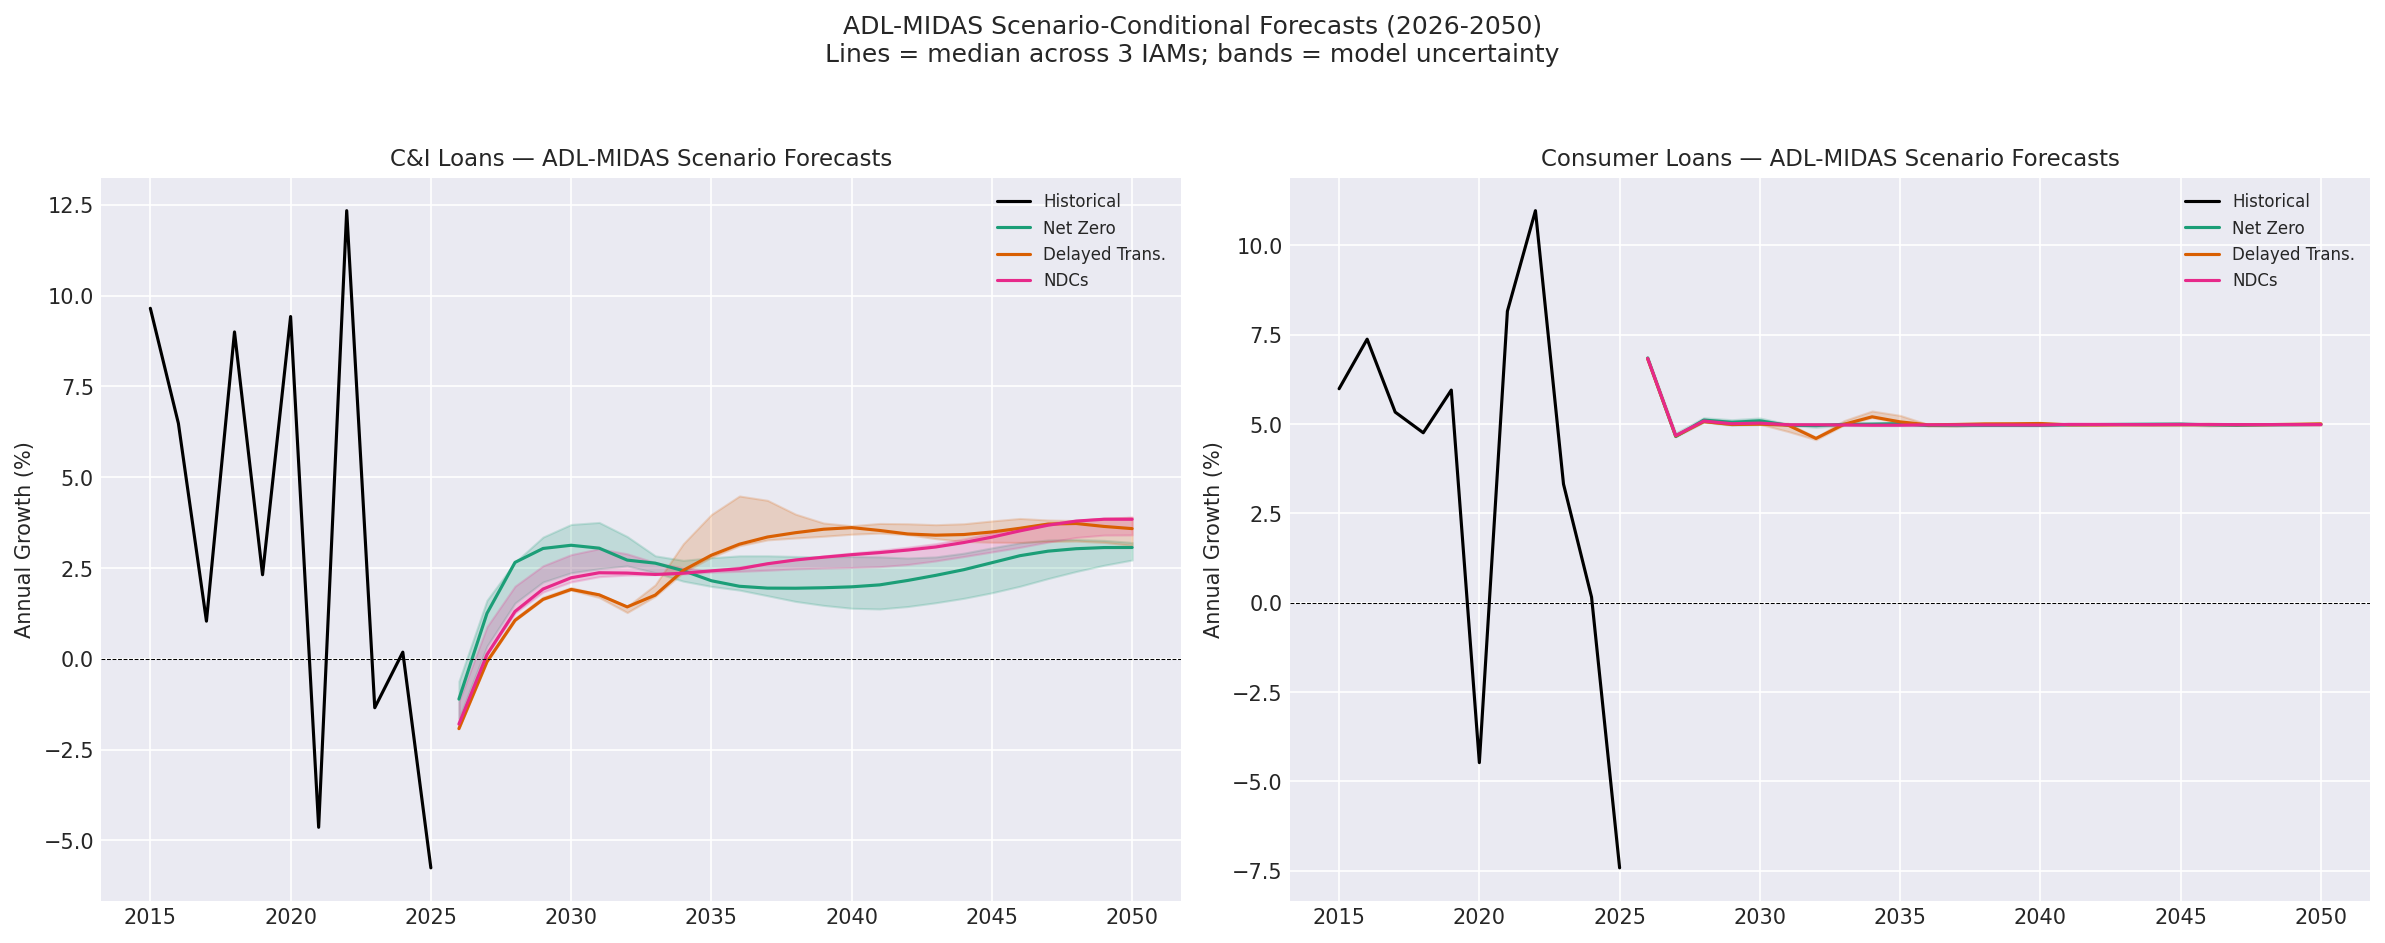

In [16]:
# Fan charts
def plot_midas_fan(forecasts, hist_series, title, ax):
    ax.plot(hist_series.index, hist_series.values, 'k-', lw=1.5, label='Historical')
    for scen in KEY_SCENARIOS:
        paths = [fc for (m, s), fc in forecasts.items() if s == scen]
        if not paths: continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo, hi = paths_df.min(axis=1), paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        label = KEY_SCENARIO_SHORT.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.2, color=color)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Annual Growth (%)')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hist_ci = annual_target.loc[2015:2025, 'BUSLOANS_g']
hist_con = annual_target.loc[2015:2025, 'CONSUMER_g']

plot_midas_fan(ci_midas_forecasts, hist_ci,
               'C&I Loans — ADL-MIDAS Scenario Forecasts', axes[0])
plot_midas_fan(con_midas_forecasts, hist_con,
               'Consumer Loans — ADL-MIDAS Scenario Forecasts', axes[1])

fig.suptitle('ADL-MIDAS Scenario-Conditional Forecasts (2026-2050)\n'
             'Lines = median across 3 IAMs; bands = model uncertainty',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}midas_scenario_fan_charts.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 8. Cumulative Impact

In [17]:
def cumulative_impact(forecasts, base=100, key_scenarios=None):
    cumul = {}
    for (model, scen), fc in forecasts.items():
        if key_scenarios and scen not in key_scenarios: continue
        levels = [base]
        for g in fc.values:
            levels.append(levels[-1] * np.exp(g / 100))
        cumul[(model, scen)] = pd.Series(levels[1:], index=fc.index)
    return cumul

ci_cumul = cumulative_impact(ci_midas_forecasts, key_scenarios=KEY_SCENARIOS)
con_cumul = cumulative_impact(con_midas_forecasts, key_scenarios=KEY_SCENARIOS)

print('ADL-MIDAS Cumulative Loan Balance Index (2025 = 100)')
print('=' * 70)
for loan_type, cumul_dict in [('C&I', ci_cumul), ('Consumer', con_cumul)]:
    print(f'\n--- {loan_type} Loans ---')
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths: continue
        paths_df = pd.concat(paths, axis=1)
        for yr in [2030, 2040, 2050]:
            if yr in paths_df.index:
                med = paths_df.loc[yr].median()
                lo, hi = paths_df.loc[yr].min(), paths_df.loc[yr].max()
                prefix = f'  {KEY_SCENARIO_SHORT.get(scen, scen):18s} |' if yr == 2030 else f'  {"":18s} |'
                print(f'{prefix} {yr}: {med:6.1f} [{lo:.1f}-{hi:.1f}]')

ADL-MIDAS Cumulative Loan Balance Index (2025 = 100)

--- C&I Loans ---
  Net Zero           | 2030:  110.3 [104.8-110.4]
                     | 2040:  137.7 [135.2-140.8]
                     | 2050:  183.6 [164.7-187.0]
  Delayed Trans.     | 2030:  102.6 [102.6-102.9]
                     | 2040:  135.1 [133.9-142.2]
                     | 2050:  196.1 [192.1-197.2]
  NDCs               | 2030:  103.8 [103.6-107.4]
                     | 2040:  133.8 [133.3-139.1]
                     | 2050:  187.9 [187.8-189.6]

--- Consumer Loans ---
  Net Zero           | 2030:  130.7 [130.3-131.1]
                     | 2040:  214.8 [214.7-215.3]
                     | 2050:  353.8 [353.2-354.6]
  Delayed Trans.     | 2030:  130.4 [130.4-130.4]
                     | 2040:  214.7 [214.7-215.0]
                     | 2050:  353.7 [353.7-353.7]
  NDCs               | 2030:  130.5 [130.5-130.8]
                     | 2040:  214.9 [214.7-214.9]
                     | 2050:  353.8 [353.8-353.9]


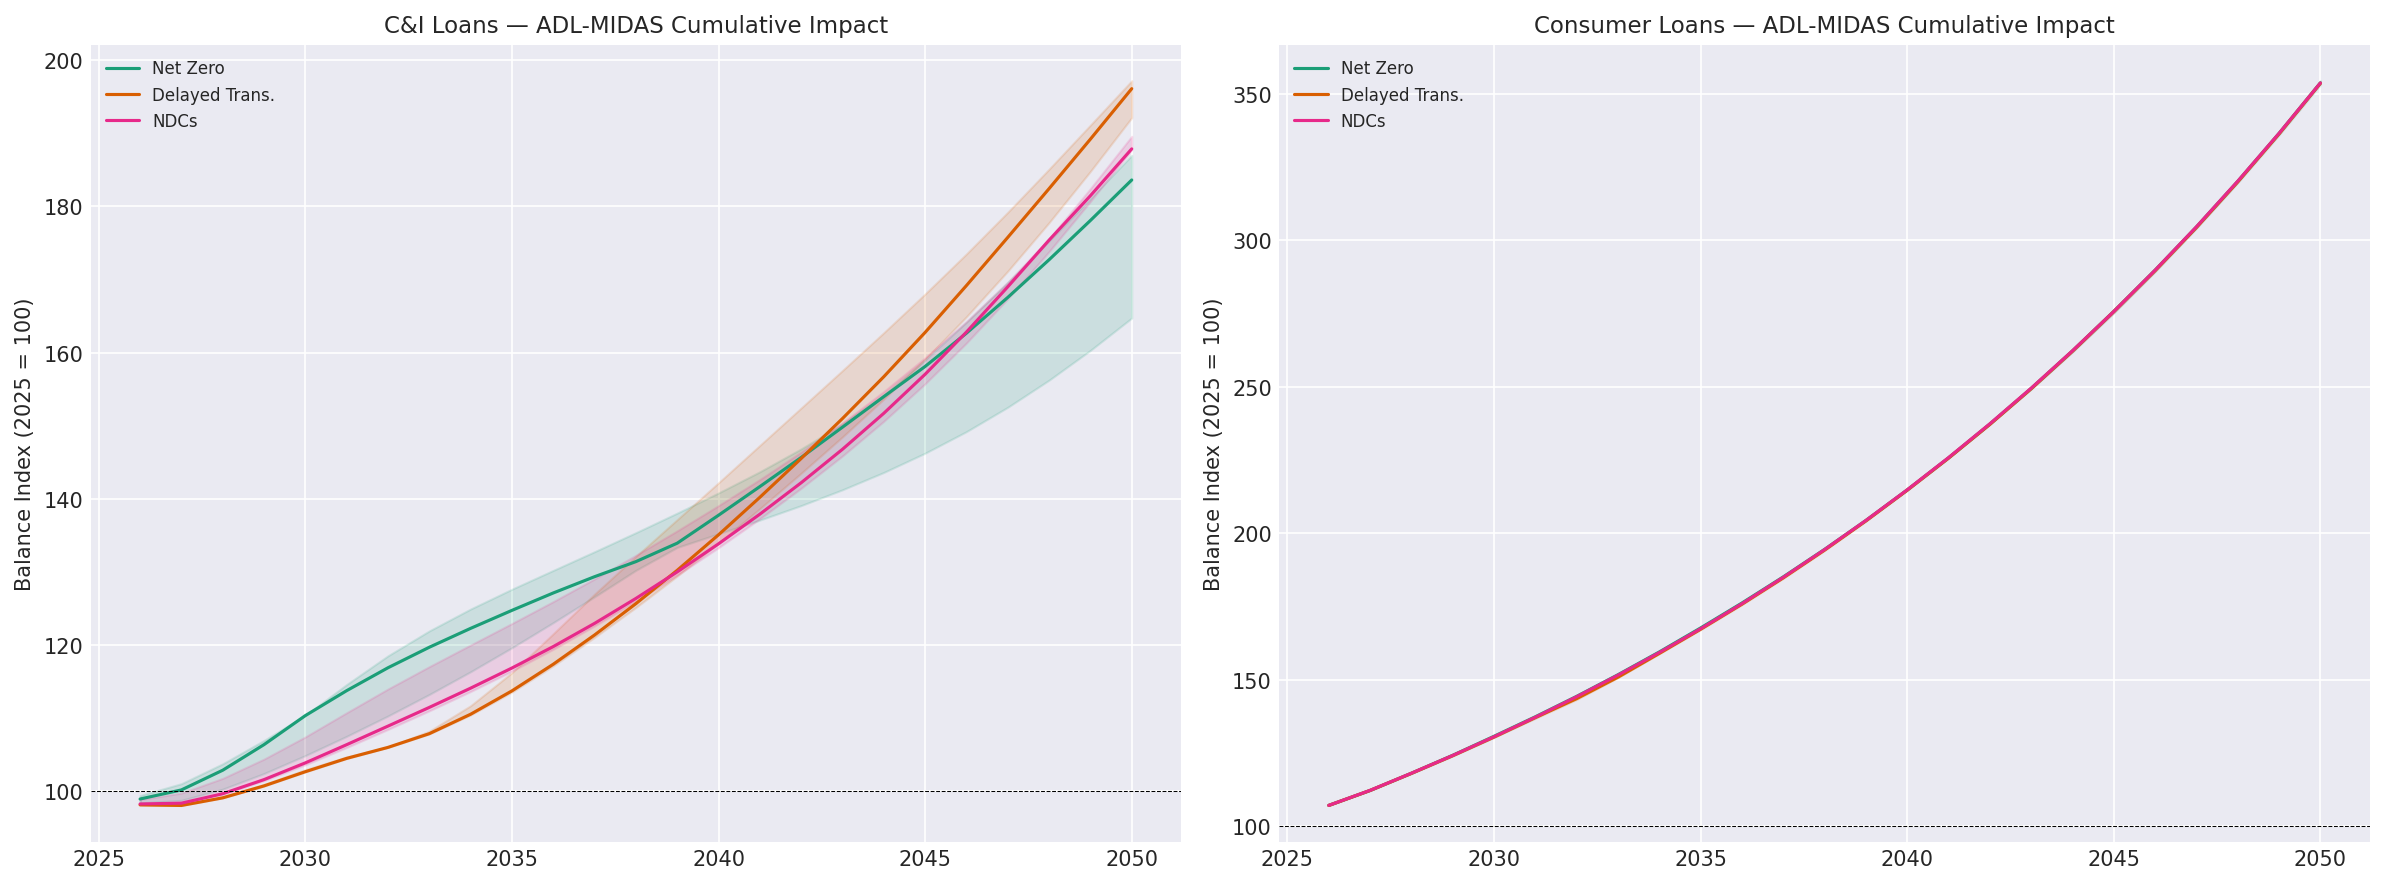

In [18]:
# Cumulative impact plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cumul_dict, title in [
    (axes[0], ci_cumul, 'C&I Loans — ADL-MIDAS Cumulative Impact'),
    (axes[1], con_cumul, 'Consumer Loans — ADL-MIDAS Cumulative Impact'),
]:
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths: continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo, hi = paths_df.min(axis=1), paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        ax.plot(median.index, median.values, '-', color=color, lw=1.5,
                label=KEY_SCENARIO_SHORT.get(scen, scen))
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.15, color=color)
    ax.axhline(100, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Balance Index (2025 = 100)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}midas_cumulative_impact.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 9. Summary: Three-Frequency Comparison

In [19]:
print('=' * 80)
print('THREE-FREQUENCY MODEL COMPARISON')
print('=' * 80)

print(f'\n{"":30s} {"Annual VAR":>14s} {"Quarterly VAR":>14s} {"ADL-MIDAS":>14s}')
print('-' * 72)
print(f'{"Frequency":30s} {"Annual":>14s} {"Quarterly":>14s} {"Monthly>Annual":>14s}')
obs_str = f'{len(y_ci_v)} (x12 mo)'
print(f'{"Observations":30s} {"36":>14s} {"142":>14s} {obs_str:>14s}')
print(f'{"Aggregation loss":30s} {"High (12>1)":>14s} {"Medium (3>1)":>14s} {"None":>14s}')
print(f'{"NGFS interpolation":30s} {"No":>14s} {"Yes (to qrtly)":>14s} {"Yes (to mthly)":>14s}')

# C&I
ci_imp = (1 - rmse_midas_ci/rmse_ar_ci)*100 if (not np.isnan(rmse_midas_ci) and rmse_ar_ci > 0) else float('nan')
ci_label = f'Yes ({ci_imp:+.1f}%)' if ci_imp > 0 else f'No ({ci_imp:+.1f}%)'
print(f'{"C&I: beats AR baseline":30s} {"No (-2.2%)":>14s} {"Yes (+11.7%)":>14s} {ci_label:>14s}')

# Consumer
con_imp = (1 - rmse_midas_con/rmse_ar_con)*100 if (not np.isnan(rmse_midas_con) and rmse_ar_con > 0) else float('nan')
con_label = f'Yes ({con_imp:+.1f}%)' if con_imp > 0 else f'No ({con_imp:+.1f}%)'
print(f'{"Consumer: beats AR baseline":30s} {"No (-28.1%)":>14s} {"Yes (+7.5%)":>14s} {con_label:>14s}')

print(f'{"Key advantage":30s} {"Interpretable":>14s} {"Most data":>14s} {"Weight insight":>14s}')
print(f'{"Key limitation":30s} {"Too few obs":>14s} {"Interp. NGFS":>14s} {"NLS convergence":>14s}')

print(f'\nMIDAS UNIQUE INSIGHT: The weight functions show WHICH MONTHS within each year')
print(f'matter most for predicting annual loan growth. This is information that neither')
print(f'the annual nor quarterly VARs can provide.')


THREE-FREQUENCY MODEL COMPARISON

                                   Annual VAR  Quarterly VAR      ADL-MIDAS
------------------------------------------------------------------------
Frequency                              Annual      Quarterly Monthly>Annual
Observations                               36            142    34 (x12 mo)
Aggregation loss                  High (12>1)   Medium (3>1)           None
NGFS interpolation                         No Yes (to qrtly) Yes (to mthly)
C&I: beats AR baseline             No (-2.2%)   Yes (+11.7%)    Yes (+1.7%)
Consumer: beats AR baseline       No (-28.1%)    Yes (+7.5%)   Yes (+21.0%)
Key advantage                   Interpretable      Most data Weight insight
Key limitation                    Too few obs   Interp. NGFS NLS convergence

MIDAS UNIQUE INSIGHT: The weight functions show WHICH MONTHS within each year
matter most for predicting annual loan growth. This is information that neither
the annual nor quarterly VARs can provide.


In [20]:
# Final diagnostics
print('=' * 70)
print('ADL-MIDAS DIAGNOSTICS SUMMARY')
print('=' * 70)

for name, result, covid_v in [
    ('C&I', ci_midas, covid_ci_v),
    ('Consumer', con_midas, covid_con_v),
]:
    resid = result['residuals'][~covid_v]
    lb = acorr_ljungbox(resid, lags=[2, 4], return_df=True)
    adf = adfuller(resid)
    print(f'\n{name} ADL-MIDAS:')
    print(f'  Observations: {len(result["residuals"])}')
    print(f'  Parameters: {len(result["params"])}')
    print(f'  RMSE (ex-COVID): {result["rmse"]:.3f}')
    print(f'  R-squared (ex-COVID): {result["r_squared"]:.3f}')
    print(f'  Ljung-Box: lag2 p={lb["lb_pvalue"].iloc[0]:.3f}, lag4 p={lb["lb_pvalue"].iloc[1]:.3f}')
    print(f'  ADF on residuals: p={adf[1]:.4f}')
    print(f'  gamma (ADL persistence): {result["gamma"]:.3f}')
    for v in result['variables']:
        print(f'  {v["name"]}: beta1={v["beta1"]:.3f}, peak month={v["peak_month"]} ({month_labels[v["peak_month"]-1]})')

print(f'\nScenario forecasts: {len(ci_midas_forecasts)} C&I + {len(con_midas_forecasts)} Consumer')
nan_count = sum(fc.isna().sum() for fc in ci_midas_forecasts.values())
nan_count += sum(fc.isna().sum() for fc in con_midas_forecasts.values())
print(f'NaN in forecasts: {nan_count}')
print(f'Figures saved to {FIG_DIR}')

ADL-MIDAS DIAGNOSTICS SUMMARY

C&I ADL-MIDAS:
  Observations: 34
  Parameters: 8
  RMSE (ex-COVID): 5.628
  R-squared (ex-COVID): 0.529
  Ljung-Box: lag2 p=0.354, lag4 p=0.227
  ADF on residuals: p=0.0524
  gamma (ADL persistence): 0.527
  UNRATE_chg: beta1=-24.736, peak month=12 (Jan)
  CPIAUCSL_g: beta1=14.376, peak month=10 (Mar)

Consumer ADL-MIDAS:
  Observations: 34
  Parameters: 8
  RMSE (ex-COVID): 5.427
  R-squared (ex-COVID): 0.192
  Ljung-Box: lag2 p=0.788, lag4 p=0.462
  ADF on residuals: p=0.0000
  gamma (ADL persistence): -0.179
  DGS10_chg: beta1=-7.324, peak month=12 (Jan)
  FEDFUNDS_chg: beta1=7.651, peak month=12 (Jan)

Scenario forecasts: 9 C&I + 9 Consumer
NaN in forecasts: 0
Figures saved to outputs/figures/
